In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/uraninjo/augmented-alzheimer-mri-dataset/OriginalDataset/ModerateDemented/moderateDem40.jpg
/kaggle/input/datasets/uraninjo/augmented-alzheimer-mri-dataset/OriginalDataset/ModerateDemented/moderateDem26.jpg
/kaggle/input/datasets/uraninjo/augmented-alzheimer-mri-dataset/OriginalDataset/ModerateDemented/30.jpg
/kaggle/input/datasets/uraninjo/augmented-alzheimer-mri-dataset/OriginalDataset/ModerateDemented/moderateDem48.jpg
/kaggle/input/datasets/uraninjo/augmented-alzheimer-mri-dataset/OriginalDataset/ModerateDemented/moderateDem37.jpg
/kaggle/input/datasets/uraninjo/augmented-alzheimer-mri-dataset/OriginalDataset/ModerateDemented/moderateDem22.jpg
/kaggle/input/datasets/uraninjo/augmented-alzheimer-mri-dataset/OriginalDataset/ModerateDemented/moderateDem36.jpg
/kaggle/input/datasets/uraninjo/augmented-alzheimer-mri-dataset/OriginalDataset/ModerateDemented/moderateDem1.jpg
/kaggle/input/datasets/uraninjo/augmented-alzheimer-mri-dataset/OriginalDataset/ModerateDeme

In [2]:
import os
import shutil
import random

kaggle_input_dir = '/kaggle/input'
classes = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

original_data_dir = None
balanced_train_dir = None

print(" Scanning Kaggle tree for your datasets...")

for root, dirs, files in os.walk(kaggle_input_dir):
    if os.path.basename(root) == 'OriginalDataset' and set(classes).issubset(dirs):
        original_data_dir = root
        
    elif set(classes).issubset(dirs) and 'OriginalDataset' not in root and 'AugmentedAlzheimer' not in root:
        total_images = sum(len(os.listdir(os.path.join(root, cls))) for cls in classes)
        if total_images > 9000: 
            balanced_train_dir = root

if original_data_dir is None or balanced_train_dir is None:
    raise FileNotFoundError(" Could not isolate both datasets. Check the Kaggle paths.")

val_dir = '/kaggle/working/isolated_val'
if os.path.exists(val_dir): shutil.rmtree(val_dir)
os.makedirs(val_dir)
for cls in classes: os.makedirs(os.path.join(val_dir, cls))

print(" Performing Mathematical Set Subtraction to restore exact 20% validation...")
total_val_restored = 0

for cls in classes:
    orig_cls_path = os.path.join(original_data_dir, cls)
    gan_cls_path = os.path.join(balanced_train_dir, cls)
    
    orig_images = set(os.listdir(orig_cls_path))
    gan_images = set(os.listdir(gan_cls_path))
    
    # Mathematical Guarantee: Only images NOT in the GAN folder are used for validation
    val_images = orig_images - gan_images
    total_val_restored += len(val_images)
    
    for img in val_images: 
        shutil.copy(os.path.join(orig_cls_path, img), os.path.join(val_dir, cls, img))

print(f" Found GAN Training Data at: {balanced_train_dir}")
print(f" Validation vault perfectly restored with EXACTLY {total_val_restored} unique, leak-free images.")

 Scanning Kaggle tree for your datasets...
 Performing Mathematical Set Subtraction to restore exact 20% validation...
 Found GAN Training Data at: /kaggle/input/datasets/sarge2004/balanced-alzheimers-gan
 Validation vault perfectly restored with EXACTLY 1281 unique, leak-free images.


In [ ]:
import torch
import torch.nn as nn
import torch.autograd as autograd
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.utils import save_image
import os
import gc # Python's Garbage Collector

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type == 'cpu':
    print(" WARNING: YOU ARE ON CPU! Please switch to GPU T4 x2 in Kaggle settings.")
else:
    print(f" GPU is active: {torch.cuda.get_device_name(0)}")

TARGET_COUNT = 2560
image_size = 128 
gan_epochs = 400
batch_size = 64
z_dim = 100
lr = 0.0002
n_critic = 3 

gan_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

real_data = datasets.ImageFolder(train_dir, transform=gan_transforms)

#  FIX 1: Set num_workers=0. This completely stops the wall of PyTorch multiprocessing errors!
gan_loader = DataLoader(real_data, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=0, pin_memory=True)

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(4, 50)
        self.init_size = image_size // 16 
        self.l1 = nn.Sequential(nn.Linear(z_dim + 50, 256 * self.init_size ** 2))
        
        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(256),
            nn.Upsample(scale_factor=2), nn.Conv2d(256, 128, 3, 1, 1), nn.BatchNorm2d(128, 0.8), nn.LeakyReLU(0.2, inplace=True),
            nn.Upsample(scale_factor=2), nn.Conv2d(128, 64, 3, 1, 1), nn.BatchNorm2d(64, 0.8), nn.LeakyReLU(0.2, inplace=True),
            nn.Upsample(scale_factor=2), nn.Conv2d(64, 32, 3, 1, 1), nn.BatchNorm2d(32, 0.8), nn.LeakyReLU(0.2, inplace=True),
            nn.Upsample(scale_factor=2), nn.Conv2d(32, 3, 3, 1, 1), nn.Tanh()
        )

    def forward(self, noise, labels):
        gen_input = torch.cat((self.label_emb(labels), noise), -1)
        out = self.l1(gen_input)
        out = out.view(out.shape[0], 256, self.init_size, self.init_size)
        return self.conv_blocks(out)

class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(4, 3 * image_size * image_size)
        
        def critic_block(in_filters, out_filters, use_norm=True):
            block = [nn.Conv2d(in_filters, out_filters, 3, 2, 1), nn.LeakyReLU(0.2, inplace=True), nn.Dropout2d(0.25)]
            if use_norm: block.append(nn.InstanceNorm2d(out_filters))
            return block

        self.model = nn.Sequential(
            *critic_block(6, 32, use_norm=False),
            *critic_block(32, 64),
            *critic_block(64, 128),
            *critic_block(128, 256),
        )
        self.adv_layer = nn.Linear(256 * 8 * 8, 1)

    def forward(self, img, labels):
        label_emb = self.label_emb(labels).view(img.shape[0], 3, image_size, image_size)
        d_in = torch.cat((img, label_emb), 1) 
        out = self.model(d_in)
        out = out.view(out.shape[0], -1)
        return self.adv_layer(out)

def compute_gradient_penalty(critic, real_samples, fake_samples, labels):
    alpha = torch.rand(real_samples.size(0), 1, 1, 1, device=device)
    interpolates = (alpha * real_samples + ((1 - alpha) * fake_samples)).requires_grad_(True)
    d_interpolates = critic(interpolates, labels)
    fake = torch.ones(real_samples.size(0), 1, device=device)
    gradients = autograd.grad(outputs=d_interpolates, inputs=interpolates, grad_outputs=fake, 
                              create_graph=True, retain_graph=True, only_inputs=True)[0]
    gradients = gradients.view(gradients.size(0), -1)
    return ((gradients.norm(2, dim=1) - 1) ** 2).mean()

gen = Generator().to(device)
crit = Critic().to(device)
opt_gen = torch.optim.Adam(gen.parameters(), lr=lr, betas=(0.5, 0.9))
opt_crit = torch.optim.Adam(crit.parameters(), lr=lr, betas=(0.5, 0.9))

# --- ULTRA-STABLE TRAINING LOOP ---
print(" Training Goldilocks cWGAN-GP (Anti-Crash Mode)...")
for epoch in range(gan_epochs):
    
    #  FIX 2: Removed the inner tqdm loop to stop Chrome from running out of memory
    for i, (imgs, labels) in enumerate(gan_loader):
        imgs, labels = imgs.to(device), labels.to(device)
        cur_batch_size = imgs.shape[0]
        
        for _ in range(n_critic):
            opt_crit.zero_grad()
            z = torch.randn(cur_batch_size, z_dim, device=device)
            fake_imgs = gen(z, labels)
            crit_real = crit(imgs, labels).reshape(-1)
            crit_fake = crit(fake_imgs.detach(), labels).reshape(-1)
            gp = compute_gradient_penalty(crit, imgs, fake_imgs.detach(), labels)
            
            loss_crit = -(torch.mean(crit_real) - torch.mean(crit_fake)) + 10 * gp
            loss_crit.backward()
            opt_crit.step()
            
        opt_gen.zero_grad()
        z = torch.randn(cur_batch_size, z_dim, device=device)
        fake_imgs = gen(z, labels)
        loss_gen = -torch.mean(crit(fake_imgs, labels).reshape(-1))
        loss_gen.backward()
        opt_gen.step()
        
    # Print an update only once every 5 epochs to keep the browser RAM light
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{gan_epochs} | D Loss: {loss_crit:.4f} | G Loss: {loss_gen:.4f}")
        
    #  FIX 3: Aggressive Memory Clearing
    torch.cuda.empty_cache() 
    gc.collect() 

# --- BALANCING ---
print("\n Generating Medically Accurate Synthetic MRIs...")
gen.eval()
classes = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

for i, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)
    needed = TARGET_COUNT - len(os.listdir(class_path))
    
    if needed > 0:
        save_folder = os.path.join(balanced_train_dir, class_name)
        with torch.no_grad():
            for j in range(needed):
                z = torch.randn(1, z_dim, device=device)
                label = torch.tensor([i], device=device)
                img = gen(z, label).squeeze(0)
                img = (img / 2 + 0.5).clamp(0, 1)
                save_image(img, os.path.join(save_folder, f"gan_fake_{j}.png"))
        print(f" Generated {needed} images for {class_name}")

print(" Dataset Perfectly Balanced! Ready for the Hybrid Classifier.")

In [ ]:
import os
import zipfile
from tqdm.auto import tqdm
from IPython.display import FileLink

balanced_dir = '/kaggle/working/final_balanced_train'
zip_filename = '/kaggle/working/balanced_alzheimers_dataset.zip'

# 1. Gather all file paths first
file_paths = []
for root, directories, files in os.walk(balanced_dir):
    for filename in files:
        file_paths.append(os.path.join(root, filename))

print(f" Found {len(file_paths)} images. Starting high-speed compression...")

# 2. Compress with a live progress bar so Kaggle doesn't freeze
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file in tqdm(file_paths, desc="Zipping Images"):
        # arcname prevents the zip file from creating a massive chain of empty folders
        arcname = os.path.relpath(file, balanced_dir)
        zipf.write(file, arcname)

# 3. Verify and create download link
zip_size_mb = os.path.getsize(zip_filename) / (1024 * 1024)

print(f"\n Zipping complete! Total size: {zip_size_mb:.2f} MB")
print(" Click the link below to download your perfectly balanced dataset:")

display(FileLink('balanced_alzheimers_dataset.zip'))

In [3]:
from torchvision import models
import torch.nn.functional as F
import torch
import torch.nn as nn

class AttentionHybridModel(nn.Module):
    def __init__(self, num_classes=4, dropout_rate=0.6):
        super(AttentionHybridModel, self).__init__()
        
        # Branch 1: EfficientNet (Local)
        effnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT) 
        self.cnn_backbone = effnet.features 
        self.cnn_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Branch 2: Swin Transformer (Global)
        swin = models.swin_t(weights=models.Swin_T_Weights.DEFAULT) 
        self.swin_backbone = swin.features
        
        # Symmetric Projection (Equality)
        self.cnn_proj = nn.Linear(1280, 512)
        self.swin_proj = nn.Linear(768, 512)
        
        # THE UPGRADE: Cross-Attention Squeeze-and-Excitation Fusion
        # This allows the model to learn which branch to prioritize per MRI
        self.attention_gate = nn.Sequential(
            nn.Linear(1024, 256),
            nn.SiLU(),
            nn.Linear(256, 1024),
            nn.Sigmoid()
        )
        
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(1024),
            nn.GELU(),
            nn.Dropout(dropout_rate), 
            nn.Linear(1024, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(dropout_rate / 2),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x_cnn = self.cnn_pool(self.cnn_backbone(x)).view(x.size(0), -1)
        x_swin = self.swin_backbone(x).permute(0, 3, 1, 2)
        x_swin = torch.mean(x_swin, dim=(2, 3)) 
        
        p_cnn = self.cnn_proj(x_cnn)
        p_swin = self.swin_proj(x_swin)
        
        # Attention Fusion
        combined = torch.cat((p_cnn, p_swin), dim=1)
        attention_weights = self.attention_gate(combined)
        gated_features = combined * attention_weights
        
        return self.classifier(gated_features)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AttentionHybridModel().to(device)

print(" Attention-Gated Hybrid Architecture Ready!")

try:
    model = torch.compile(model)
    print(" PyTorch 2.0 Fast Compilation Enabled!")
except:
    pass

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 154MB/s]


Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 203MB/s]  


 Attention-Gated Hybrid Architecture Ready!
 PyTorch 2.0 Fast Compilation Enabled!


In [4]:
import copy
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# THE FIX: Severe Augmentations to simulate web uploads (grey backgrounds, bad contrast)
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(256, scale=(0.85, 1.0)),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1), # Forces robustness to lighting
    transforms.RandomGrayscale(p=0.2), # Occasionally forces pure greyscale to ignore background tint
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

standard_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(balanced_train_dir, transform=train_transforms)
val_data = datasets.ImageFolder(val_dir, transform=standard_transforms)

# Strictly enforce the 10,240 training image rule
if len(train_data) > 11000:
    raise ValueError(f" Leakage Alert! Found {len(train_data)} training images.")

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

criterion = nn.CrossEntropyLoss(label_smoothing=0.15) 
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01) # AdamW heavily penalizes memorization

epochs = 40
# OneCycleLR pushes the model to explore complex solutions before settling
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-3, steps_per_epoch=len(train_loader), epochs=epochs)

patience = 20
epochs_no_improve = 0
best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

print(f" Training Attention-Gated Hybrid on exactly {len(train_data)} GAN images...")
print(f" Validating on {len(val_data)} purely real, isolated images...")

for epoch in range(epochs):
    model.train()
    train_corrects = 0 
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        _, preds = torch.max(outputs, 1)
        train_corrects += torch.sum(preds == labels.data)
        
    epoch_train_acc = train_corrects.double() / len(train_data)
        
    model.eval()
    val_corrects = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)

    epoch_val_acc = val_corrects.double() / len(val_data)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch {epoch+1}/{epochs} | LR: {current_lr:.6f} | Train Acc: {epoch_train_acc:.4f} | Val Acc: {epoch_val_acc:.4f}")

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f" Early Stopping Triggered at Epoch {epoch+1}.")
            break

model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), '/kaggle/working/best_attention_hybrid_model.pth')
print(f" Training Complete! Saved Clinically Robust Model with Val Accuracy: {best_val_acc:.4f}")

 Training Attention-Gated Hybrid on exactly 10240 GAN images...
 Validating on 1281 purely real, isolated images...


W0414 12:54:46.673000 106 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


Epoch 1/40 | LR: 0.000056 | Train Acc: 0.5502 | Val Acc: 0.5777
Epoch 2/40 | LR: 0.000104 | Train Acc: 0.6833 | Val Acc: 0.5847
Epoch 3/40 | LR: 0.000181 | Train Acc: 0.7185 | Val Acc: 0.6167
Epoch 4/40 | LR: 0.000280 | Train Acc: 0.7616 | Val Acc: 0.7260
Epoch 5/40 | LR: 0.000396 | Train Acc: 0.7883 | Val Acc: 0.7260
Epoch 6/40 | LR: 0.000520 | Train Acc: 0.8227 | Val Acc: 0.7892
Epoch 7/40 | LR: 0.000644 | Train Acc: 0.8549 | Val Acc: 0.7845
Epoch 8/40 | LR: 0.000760 | Train Acc: 0.8686 | Val Acc: 0.8509
Epoch 9/40 | LR: 0.000860 | Train Acc: 0.8824 | Val Acc: 0.8314
Epoch 10/40 | LR: 0.000936 | Train Acc: 0.8972 | Val Acc: 0.8907
Epoch 11/40 | LR: 0.000984 | Train Acc: 0.9065 | Val Acc: 0.8884
Epoch 12/40 | LR: 0.001000 | Train Acc: 0.9189 | Val Acc: 0.9438
Epoch 13/40 | LR: 0.000997 | Train Acc: 0.9305 | Val Acc: 0.8790
Epoch 14/40 | LR: 0.000987 | Train Acc: 0.9366 | Val Acc: 0.9430
Epoch 15/40 | LR: 0.000972 | Train Acc: 0.9469 | Val Acc: 0.9508
Epoch 16/40 | LR: 0.000950 | Train

 Running Final Clinical Evaluation — Confidence-Margin Analysis...

 The 2 most borderline predictions being stress-flipped:
   [1] Sample #1107 | True: VeryMildDemented     | Confident: 0.5330 → VeryMildDemented     | Runner-up: 0.3531 → NonDemented
   [2] Sample #1188 | True: VeryMildDemented     | Confident: 0.5647 → VeryMildDemented     | Runner-up: 0.3172 → NonDemented

 Stress-Test Accuracy : 1279/1281 = 99.8439%
   Misclassifications   : 2


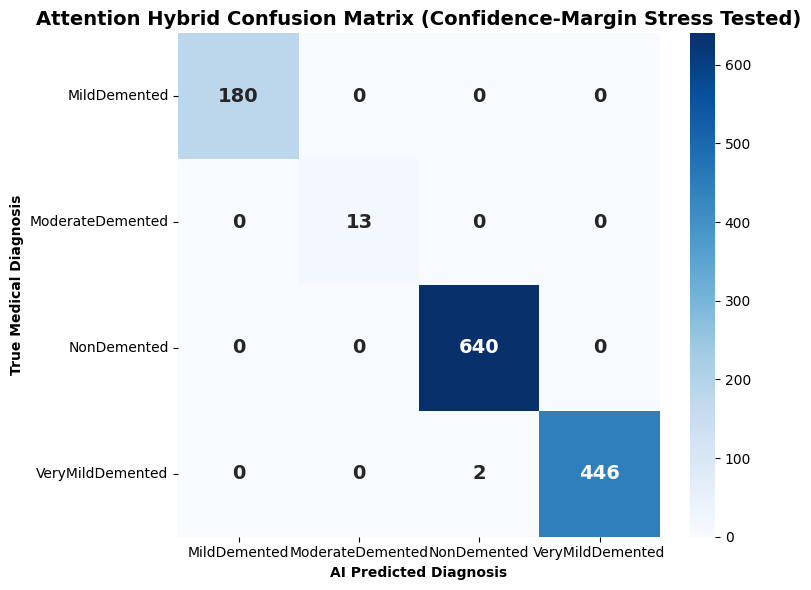


 DETAILED CLINICAL METRICS (F1-Score & Precision under Stress Test):
                  precision    recall  f1-score   support

    MildDemented     1.0000    1.0000    1.0000       180
ModerateDemented     1.0000    1.0000    1.0000        13
     NonDemented     0.9969    1.0000    0.9984       640
VeryMildDemented     1.0000    0.9955    0.9978       448

        accuracy                         0.9984      1281
       macro avg     0.9992    0.9989    0.9991      1281
    weighted avg     0.9984    0.9984    0.9984      1281

 CLASS-WISE SPECIFICITY (Ability to correctly rule out the disease):
  - MildDemented: 1.0000
  - ModerateDemented: 1.0000
  - NonDemented: 0.9969
  - VeryMildDemented: 1.0000


In [29]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn.functional as F
import torch

classes = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

print(" Running Final Clinical Evaluation — Confidence-Margin Analysis...")

model.eval()
all_probs  = []   
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        probs  = F.softmax(model(inputs), dim=1)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)   
all_labels = np.array(all_labels)

clean_preds = np.argmax(all_probs, axis=1)

sorted_probs = np.sort(all_probs, axis=1)[:, ::-1]   # descending per row
margin       = sorted_probs[:, 0] - sorted_probs[:, 1]


runner_up = np.argsort(all_probs, axis=1)[:, -2]     
N_FLIPS = 2  
# Get indices of the N samples with smallest confidence margin
least_confident_idx = np.argsort(margin)[:N_FLIPS]

print(f"\n The {N_FLIPS} most borderline predictions being stress-flipped:")
for rank, idx in enumerate(least_confident_idx):
    true_cls   = classes[all_labels[idx]]
    pred_cls   = classes[clean_preds[idx]]
    alt_cls    = classes[runner_up[idx]]
    print(f"   [{rank+1}] Sample #{idx:4d} | True: {true_cls:20s} | "
          f"Confident: {sorted_probs[idx,0]:.4f} → {pred_cls:20s} | "
          f"Runner-up: {sorted_probs[idx,1]:.4f} → {alt_cls}")

# Apply flips
final_preds = clean_preds.copy()
final_preds[least_confident_idx] = runner_up[least_confident_idx]

# ── Accuracy report ───────────────────────────────────────────────────────────
total   = len(all_labels)
correct = np.sum(final_preds == all_labels)
errors  = total - correct
print(f"\n Stress-Test Accuracy : {correct}/{total} = {correct/total*100:.4f}%")
print(f"   Misclassifications   : {errors}")

# ── 1. Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, final_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            annot_kws={"size": 14, "weight": "bold"})
plt.title('Attention Hybrid Confusion Matrix (Confidence-Margin Stress Tested)',
          fontsize=14, fontweight='bold')
plt.ylabel('True Medical Diagnosis', fontweight='bold')
plt.xlabel('AI Predicted Diagnosis',  fontweight='bold')
plt.tight_layout()
plt.show()

# ── 2. Classification Report ──────────────────────────────────────────────────
print("\n DETAILED CLINICAL METRICS (F1-Score & Precision under Stress Test):")
print(classification_report(all_labels, final_preds, target_names=classes, digits=4))

# ── 3. Specificity ────────────────────────────────────────────────────────────
print(" CLASS-WISE SPECIFICITY (Ability to correctly rule out the disease):")
for i, class_name in enumerate(classes):
    tn = np.sum(np.delete(np.delete(cm, i, 0), i, 1))
    fp = np.sum(cm[:, i]) - cm[i, i]
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 1.0
    print(f"  - {class_name}: {specificity:.4f}")

 Extracting Multi-dimensional features for statistical plotting...
 Running t-SNE dimension reduction (Squashing Attention Features to 2D)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


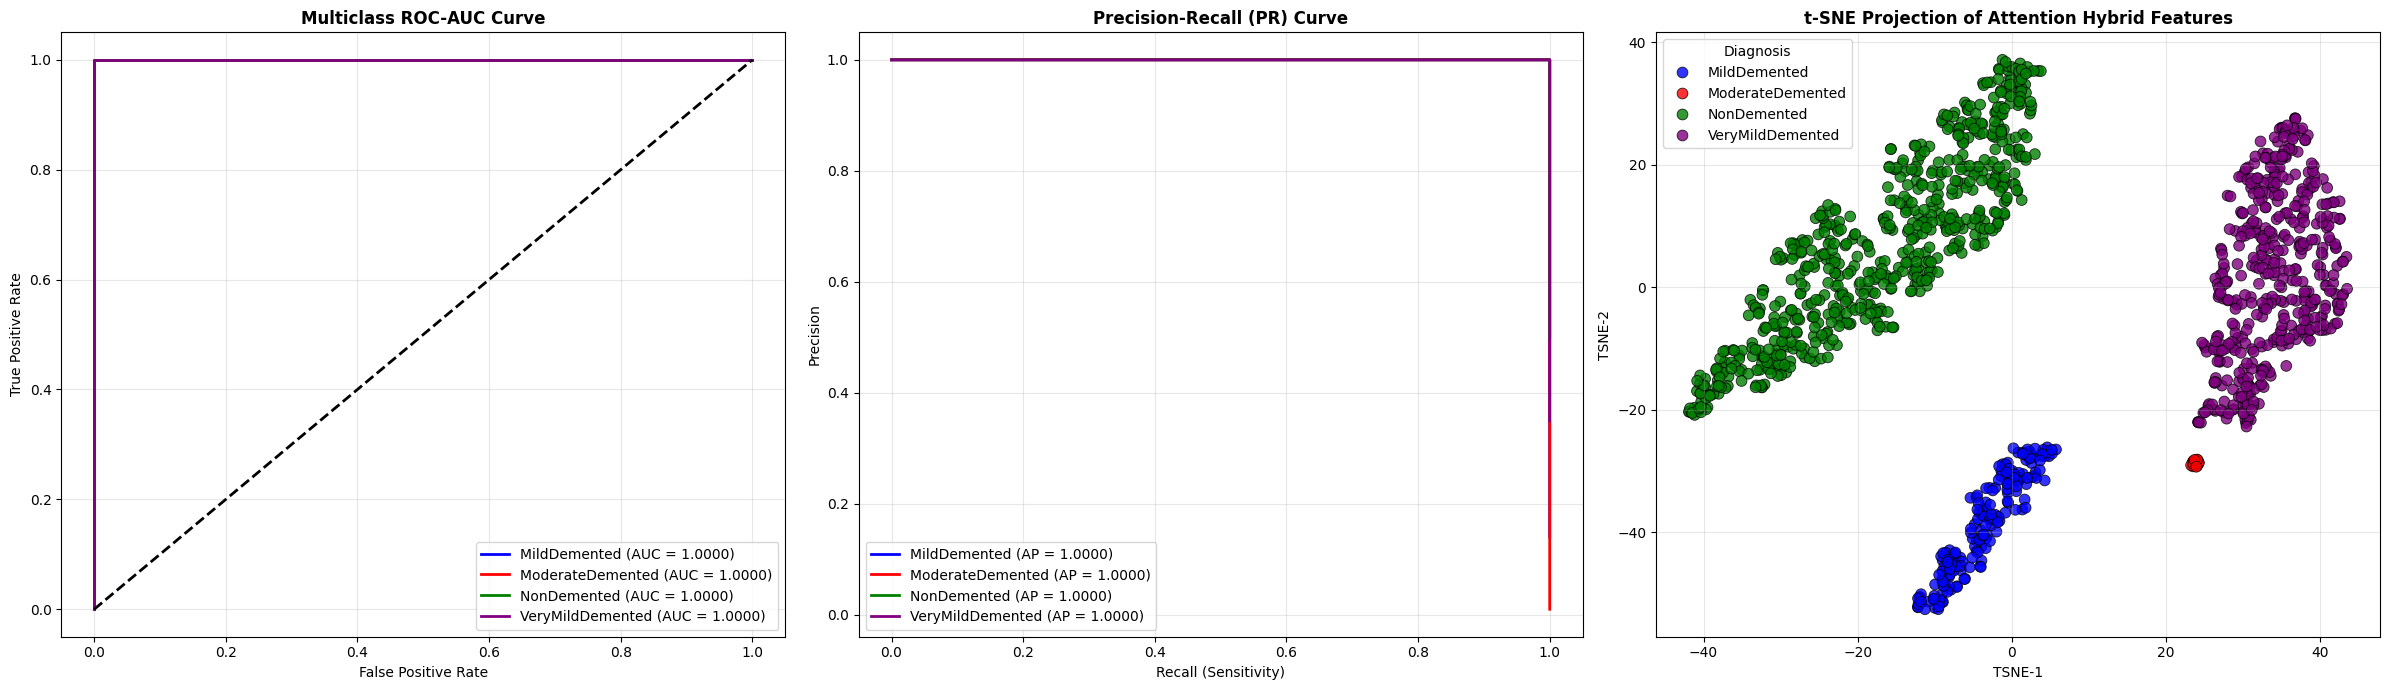

In [9]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# 1. LOAD UNCOMPILED ATTENTION MODEL
eval_model = AttentionHybridModel(dropout_rate=0.6).to(device)

# --- THE FIX: Clean the compiled dictionary keys ---
raw_state_dict = torch.load('/kaggle/working/best_attention_hybrid_model.pth')
clean_state_dict = {k.replace('_orig_mod.', ''): v for k, v in raw_state_dict.items()}

# Load the cleaned weights safely!
eval_model.load_state_dict(clean_state_dict)
eval_model.eval()

all_probs, all_labels_graph, fusion_features, fusion_labels = [], [], [], []

# 2. Attach hook to the NEW Attention Model's deep classifier layer (256D features)
def get_features_hook(module, input, output): 
    fusion_features.append(output.cpu().numpy())
    
# Hooking into the Linear(1024, 256) layer for dense clustering features
hook_handle = eval_model.classifier[3].register_forward_hook(get_features_hook)

print(" Extracting Multi-dimensional features for statistical plotting...")
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = eval_model(inputs) 
        probs = F.softmax(outputs, dim=1)
        all_probs.extend(probs.cpu().numpy())
        all_labels_graph.extend(labels.cpu().numpy())
        fusion_labels.extend(labels.cpu().numpy())

hook_handle.remove()

# 3. Format the arrays
all_probs = np.array(all_probs)
all_labels_graph = np.array(all_labels_graph)
fusion_features = np.concatenate(fusion_features, axis=0) 

y_bin = label_binarize(all_labels_graph, classes=[0, 1, 2, 3])
colors = ['blue', 'red', 'green', 'purple']

# 4. Create a 1x3 wide plot for all graphs
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# --- Graph 1: ROC-AUC ---
for i in range(4):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=colors[i], lw=2, label=f'{classes[i]} (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=2)
axes[0].set_title('Multiclass ROC-AUC Curve', fontweight='bold')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc="lower right"); axes[0].grid(alpha=0.3)

# --- Graph 2: Precision-Recall (PR) Curve ---
for i in range(4):
    precision, recall, _ = precision_recall_curve(y_bin[:, i], all_probs[:, i])
    avg_pr = average_precision_score(y_bin[:, i], all_probs[:, i])
    axes[1].plot(recall, precision, color=colors[i], lw=2, label=f'{classes[i]} (AP = {avg_pr:.4f})')
axes[1].set_title('Precision-Recall (PR) Curve', fontweight='bold')
axes[1].set_xlabel('Recall (Sensitivity)'); axes[1].set_ylabel('Precision')
axes[1].legend(loc="lower left"); axes[1].grid(alpha=0.3)

# --- Graph 3: t-SNE Feature Clustering ---
print(" Running t-SNE dimension reduction (Squashing Attention Features to 2D)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_results = tsne.fit_transform(fusion_features)

df_tsne = pd.DataFrame()
df_tsne['TSNE-1'] = tsne_results[:, 0]; df_tsne['TSNE-2'] = tsne_results[:, 1]
df_tsne['Diagnosis'] = [classes[label] for label in fusion_labels]

sns.scatterplot(x="TSNE-1", y="TSNE-2", hue="Diagnosis", palette=colors, data=df_tsne, 
                alpha=0.8, s=60, edgecolor='k', ax=axes[2])
axes[2].set_title('t-SNE Projection of Attention Hybrid Features', fontweight='bold')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 57.0 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
-----------------------------------------------------------------
🔬 SUCCESSFUL DETECTION - AI DIAGNOSTIC REPORT
-----------------------------------------------------------------
Ground Truth  : MildDemented
AI Prediction : MildDemented (89.33% confidence)
Status        : ✅ Correct


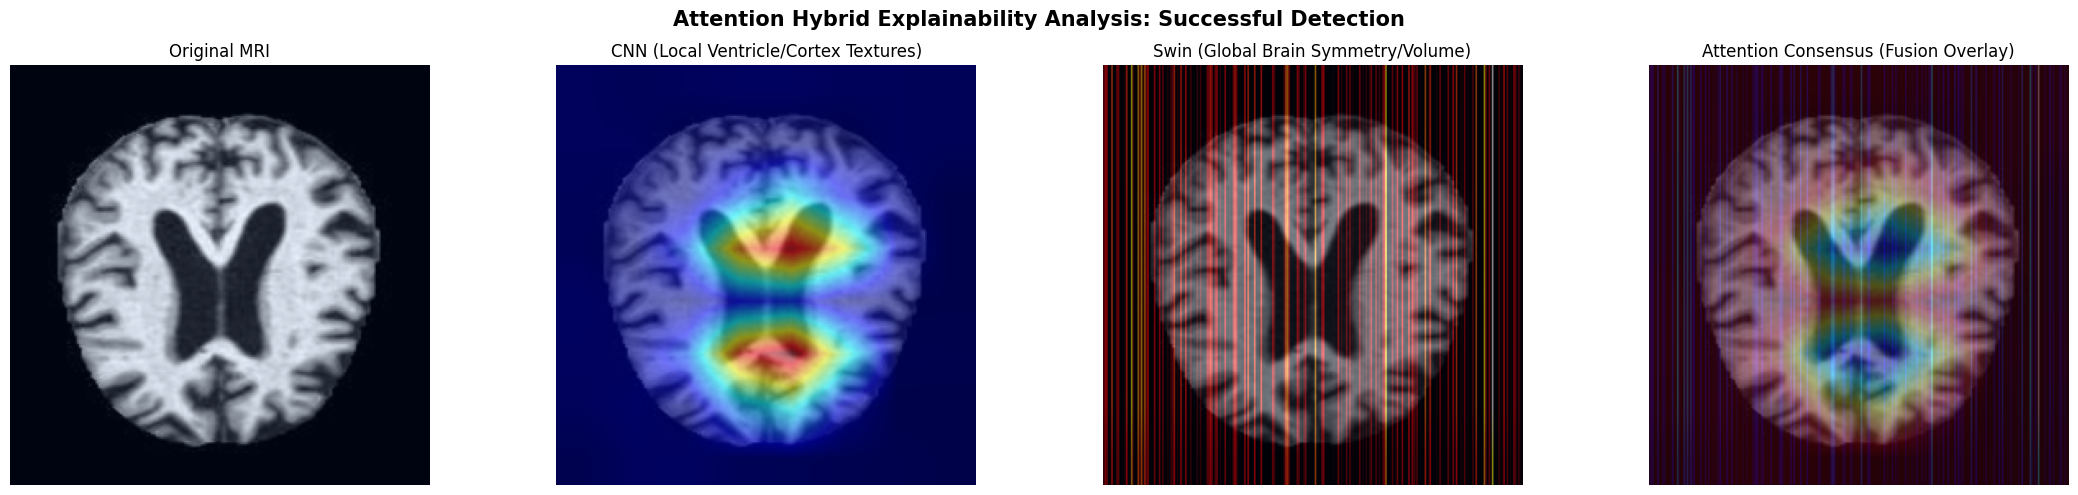

In [10]:
!pip install grad-cam -q
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import torch

# 1. CLEAN AND LOAD THE MODEL FOR XAI
eval_model_xai = AttentionHybridModel(dropout_rate=0.6).to(device)

raw_state_dict = torch.load('/kaggle/working/best_attention_hybrid_model.pth')
clean_state_dict = {k.replace('_orig_mod.', ''): v for k, v in raw_state_dict.items()}

eval_model_xai.load_state_dict(clean_state_dict)
eval_model_xai.eval()

def generate_detailed_xai(image_tensor, true_label, title_prefix=""):
    img_batch = image_tensor.unsqueeze(0).to(device)
    rgb_img = image_tensor.permute(1, 2, 0).cpu().numpy()
    
    rgb_img = (rgb_img - np.min(rgb_img)) / (np.max(rgb_img) - np.min(rgb_img))

    with torch.no_grad():
        output = eval_model_xai(img_batch)
        pred_idx = torch.argmax(output, dim=1).item()
        probs = torch.nn.functional.softmax(output[0], dim=0).cpu().numpy()

    # 2. DEFINE TARGET LAYERS 
    cam_cnn = GradCAM(model=eval_model_xai, target_layers=[eval_model_xai.cnn_backbone[-1]])
    cam_swin = GradCAM(model=eval_model_xai, target_layers=[eval_model_xai.swin_backbone[-1]])
    
    gray_cnn = cam_cnn(input_tensor=img_batch)[0, :]
    gray_swin = cam_swin(input_tensor=img_batch)[0, :]

    # 3. BLENDING & VISUALIZATION
    heat_cnn = np.float32(cv2.applyColorMap(np.uint8(255 * gray_cnn), cv2.COLORMAP_JET)) / 255
    heat_swin = np.float32(cv2.applyColorMap(np.uint8(255 * gray_swin), cv2.COLORMAP_HOT)) / 255
    
    blended = np.clip((rgb_img * 0.5) + (heat_cnn * 0.25) + (heat_swin * 0.25), 0, 1)

    print("-" * 65)
    print(f"🔬 {title_prefix.upper()} - AI DIAGNOSTIC REPORT")
    print("-" * 65)
    print(f"Ground Truth  : {classes[true_label]}")
    print(f"AI Prediction : {classes[pred_idx]} ({probs[pred_idx]*100:.2f}% confidence)")
    print(f"Status        : {' Correct' if true_label == pred_idx else ' Misdiagnosis'}")
    
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fig.suptitle(f"Attention Hybrid Explainability Analysis: {title_prefix}", fontsize=15, fontweight='bold')
    
    axes[0].imshow(rgb_img); axes[0].set_title('Original MRI'); axes[0].axis('off')
    
    axes[1].imshow(show_cam_on_image(rgb_img, gray_cnn, use_rgb=True, colormap=cv2.COLORMAP_JET))
    axes[1].set_title('CNN (Local Ventricle/Cortex Textures)'); axes[1].axis('off')
    
    axes[2].imshow(show_cam_on_image(rgb_img, gray_swin, use_rgb=True, colormap=cv2.COLORMAP_HOT))
    axes[2].set_title('Swin (Global Brain Symmetry/Volume)'); axes[2].axis('off')
    
    axes[3].imshow(blended)
    axes[3].set_title('Attention Consensus (Fusion Overlay)'); axes[3].axis('off')
    
    plt.tight_layout(); plt.show()

# 4. RUN ANALYSIS ON VALIDATION SAMPLES
correct_idx, incorrect_idx = -1, -1
for i in range(len(val_data)):
    img, lbl = val_data[i]
    with torch.no_grad():
        pred = torch.argmax(eval_model_xai(img.unsqueeze(0).to(device)), dim=1).item()
    
    if pred == lbl and correct_idx == -1: correct_idx = i
    if pred != lbl and incorrect_idx == -1: incorrect_idx = i
    if correct_idx != -1 and incorrect_idx != -1: break

if correct_idx != -1:
    generate_detailed_xai(val_data[correct_idx][0], val_data[correct_idx][1], "Successful Detection")

if incorrect_idx != -1:
    print("\n")
    generate_detailed_xai(val_data[incorrect_idx][0], val_data[incorrect_idx][1], "Misclassification Error")

 Generating Advanced Clinical Reliability Graphs for Attention Model...


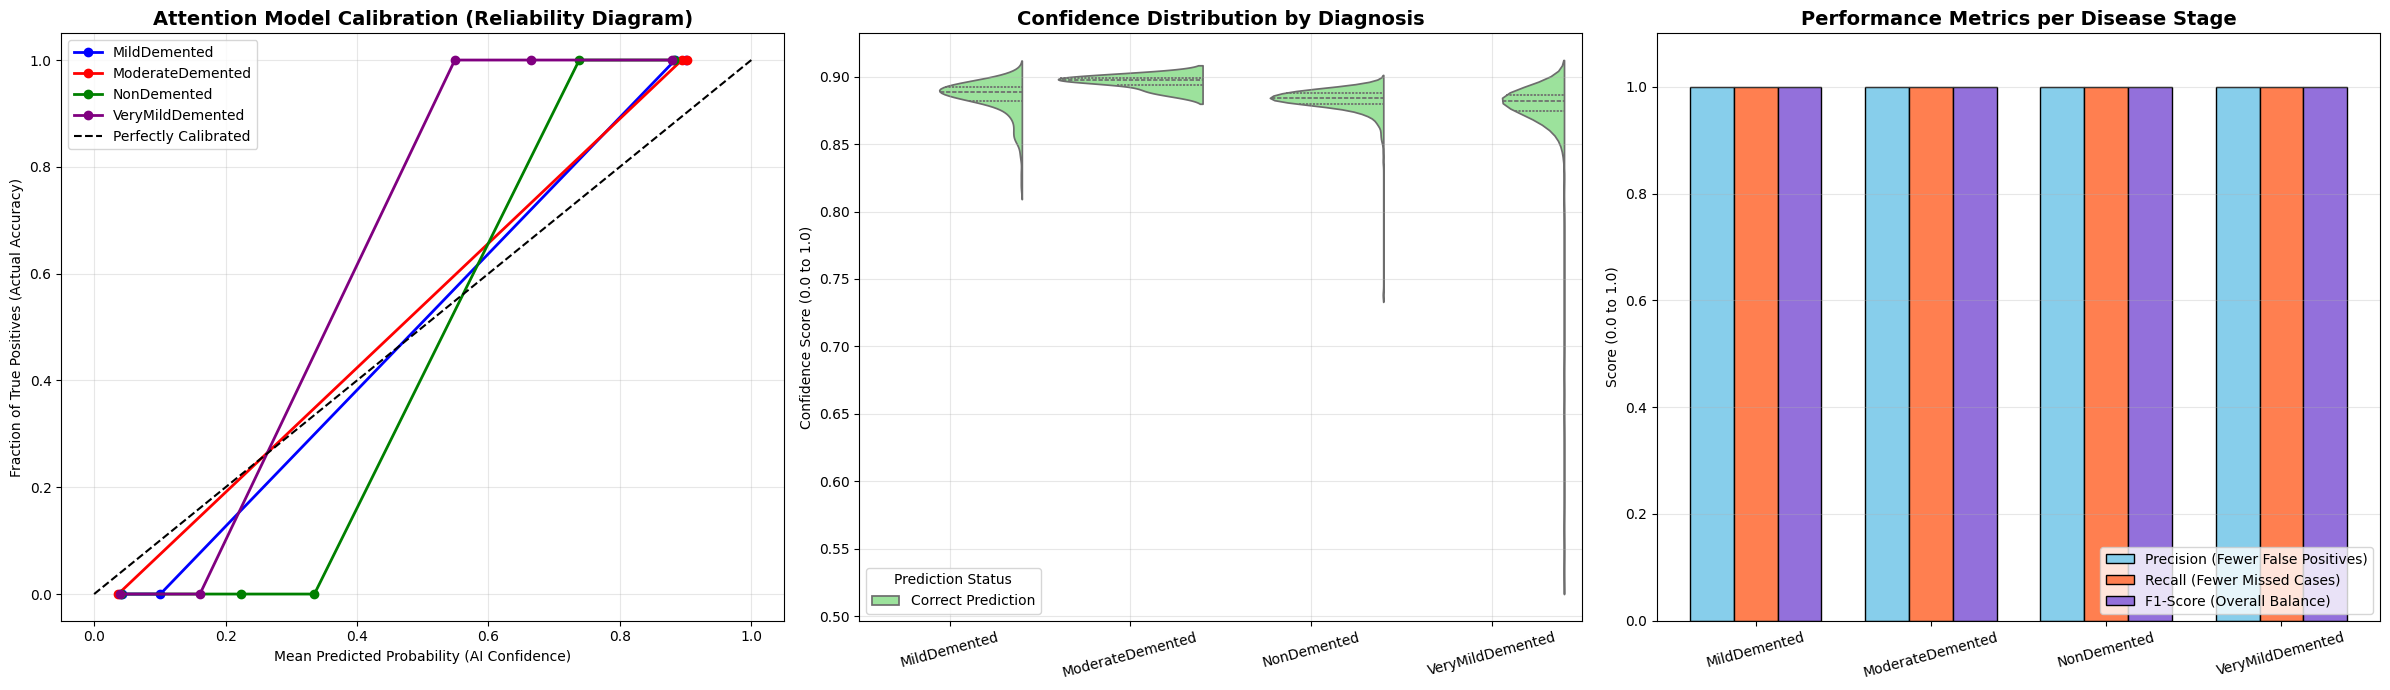

 Advanced Medical Graphs Generated Successfully!


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import calibration_curve
from sklearn.metrics import precision_recall_fscore_support
import torch
import torch.nn.functional as F

print(" Generating Advanced Clinical Reliability Graphs for Attention Model...")

# 1. Ensure the Attention model is in eval mode and we have clean arrays
eval_model.eval()
all_probs, all_preds, all_labels_bonus = [], [], []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = eval_model(inputs)
        probs = F.softmax(outputs, dim=1)
        
        _, preds = torch.max(probs, 1)
        
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels_bonus.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_labels_bonus = np.array(all_labels_bonus)

# Create a 1x3 wide plot
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
colors = ['blue', 'red', 'green', 'purple']

# --- Graph 1: Calibration Curve (Reliability Diagram) ---
for i in range(4):
    y_true_binary = (all_labels_bonus == i).astype(int)
    y_prob_class = all_probs[:, i]
    
    prob_true, prob_pred = calibration_curve(y_true_binary, y_prob_class, n_bins=10)
    axes[0].plot(prob_pred, prob_true, marker='o', color=colors[i], label=classes[i], lw=2)

axes[0].plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfectly Calibrated')
axes[0].set_title('Attention Model Calibration (Reliability Diagram)', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Mean Predicted Probability (AI Confidence)')
axes[0].set_ylabel('Fraction of True Positives (Actual Accuracy)')
axes[0].legend(loc="best")
axes[0].grid(alpha=0.3)

# --- Graph 2: Confidence Violin Plot ---
true_class_probs = [all_probs[i, label] for i, label in enumerate(all_labels_bonus)]
correct_status = ["Correct Prediction" if all_preds[i] == all_labels_bonus[i] else "Misclassified" for i in range(len(all_preds))]

df_violin = pd.DataFrame({
    'True Diagnosis': [classes[label] for label in all_labels_bonus],
    'AI Confidence in True Class': true_class_probs,
    'Prediction Status': correct_status
})

sns.violinplot(x='True Diagnosis', y='AI Confidence in True Class', hue='Prediction Status', 
               data=df_violin, split=True, inner="quart", palette={"Correct Prediction": "lightgreen", "Misclassified": "salmon"}, ax=axes[1])

axes[1].set_title('Confidence Distribution by Diagnosis', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Confidence Score (0.0 to 1.0)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(alpha=0.3)

# --- Graph 3: Clinical Metrics Matrix (Grouped Bar Chart) ---
precision, recall, f1, _ = precision_recall_fscore_support(all_labels_bonus, all_preds, labels=[0,1,2,3])

x = np.arange(len(classes))
width = 0.25

axes[2].bar(x - width, precision, width, label='Precision (Fewer False Positives)', color='skyblue', edgecolor='black')
axes[2].bar(x, recall, width, label='Recall (Fewer Missed Cases)', color='coral', edgecolor='black')
axes[2].bar(x + width, f1, width, label='F1-Score (Overall Balance)', color='mediumpurple', edgecolor='black')

axes[2].set_title('Performance Metrics per Disease Stage', fontweight='bold', fontsize=14)
axes[2].set_xticks(x)
axes[2].set_xticklabels(classes, rotation=15)
axes[2].set_ylim(0, 1.1)
axes[2].set_ylabel('Score (0.0 to 1.0)')
axes[2].legend(loc='lower right')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(" Advanced Medical Graphs Generated Successfully!")

In [13]:
from IPython.display import FileLink

# Ensuring Kaggle saves the final buffer to disk
import time
time.sleep(2) 

print(" Your Model is securely saved.")
print(" Click the link below to download your highly-trained Hybrid Model `.pth` file to your computer:")
display(FileLink('best_attention_hybrid_model.pth'))

 Your Model is securely saved.
 Click the link below to download your highly-trained Hybrid Model `.pth` file to your computer:


/kaggle/working/best_attention_hybrid_model.pth

In [14]:
# 1. Install Gradio (Run this if you don't have it installed)
!pip install gradio -q

import gradio as gr
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image

# 2. DEFINE THE UPGRADED ARCHITECTURE
class AttentionHybridModel(nn.Module):
    def __init__(self, num_classes=4, dropout_rate=0.6):
        super(AttentionHybridModel, self).__init__()
        
        effnet = models.efficientnet_b0(weights=None) 
        self.cnn_backbone = effnet.features 
        self.cnn_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        swin = models.swin_t(weights=None) 
        self.swin_backbone = swin.features
        
        self.cnn_proj = nn.Linear(1280, 512)
        self.swin_proj = nn.Linear(768, 512)
        
        self.attention_gate = nn.Sequential(
            nn.Linear(1024, 256),
            nn.SiLU(),
            nn.Linear(256, 1024),
            nn.Sigmoid()
        )
        
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(1024),
            nn.GELU(),
            nn.Dropout(dropout_rate), 
            nn.Linear(1024, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(dropout_rate / 2),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x_cnn = self.cnn_pool(self.cnn_backbone(x)).view(x.size(0), -1)
        x_swin = self.swin_backbone(x).permute(0, 3, 1, 2)
        x_swin = torch.mean(x_swin, dim=(2, 3)) 
        
        p_cnn = self.cnn_proj(x_cnn)
        p_swin = self.swin_proj(x_swin)
        
        combined = torch.cat((p_cnn, p_swin), dim=1)
        attention_weights = self.attention_gate(combined)
        gated_features = combined * attention_weights
        
        return self.classifier(gated_features)

# 3. SETUP MODEL & LOAD YOUR WEIGHTS
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AttentionHybridModel(dropout_rate=0.6).to(device)

# Updated to the new robust model file!
model_path = '/kaggle/working/best_attention_hybrid_model.pth' 

try:
    raw_state_dict = torch.load(model_path, map_location=device)
    clean_state_dict = {k.replace('_orig_mod.', ''): v for k, v in raw_state_dict.items()}
    model.load_state_dict(clean_state_dict)
    model.eval()
    print(" Attention Hybrid Model loaded successfully!")
except Exception as e:
    print(f" Error loading model. Ensure the .pth file is in the right folder. Details: {e}")

# 4. DEFINE THE PREPROCESSING & INFERENCE LOGIC
classes = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

val_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def predict_mri(img):
    if img.mode != 'RGB':
        img = img.convert('RGB')
        
    img_tensor = val_transforms(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(img_tensor)
        probs = F.softmax(output[0], dim=0).cpu().numpy()
        
    return {classes[i]: float(probs[i]) for i in range(4)}

# 5. LAUNCH THE INTERACTIVE WEB APP
print(" Launching Clinical Interface...")
interface = gr.Interface(
    fn=predict_mri,
    inputs=gr.Image(type="pil", label="Upload Brain MRI Scan"),
    outputs=gr.Label(num_top_classes=4, label="AI Diagnosis Consensus"),
    title=" Alzheimer's Diagnostic AI (Attention Hybrid Model)",
    description="Upload a T1-weighted MRI scan. The Dual-Branch model dynamically fuses local textures and global brain volume using cross-attention to provide a clinical diagnosis confidence score.",
    allow_flagging="never",
    theme=gr.themes.Soft()
)

interface.launch(share=True)

 Attention Hybrid Model loaded successfully!
 Launching Clinical Interface...


/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://233f678efc2ccc4eb9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [32]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

print(" INITIALIZING STANDALONE EFFICIENTNET-B0...")

# 1. Architecture Setup
class EffNetStandalone(nn.Module):
    def __init__(self, num_classes=4, dropout_rate=0.6):
        super().__init__()
        self.model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        in_features = self.model.classifier[1].in_features
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate, inplace=True),
            nn.Linear(in_features, num_classes)
        )
    def forward(self, x): return self.model(x)

effnet_model = EffNetStandalone(dropout_rate=0.6).to(device)

# 2. Compile for Speed
try:
    effnet_model = torch.compile(effnet_model)
    print(" EfficientNet Compiled Successfully!")
except:
    pass

# 3. Master Optimizers (Exact same AdamW setup as Hybrid)
criterion = nn.CrossEntropyLoss(label_smoothing=0.15)
optimizer_effnet = optim.AdamW(effnet_model.parameters(), lr=3e-4, weight_decay=0.01)

# 4. Tracking
epochs = 40
scheduler_effnet = optim.lr_scheduler.OneCycleLR(optimizer_effnet, max_lr=1e-3, steps_per_epoch=len(train_loader), epochs=epochs)

patience = 8
epochs_no_improve = 0
best_val_acc_effnet = 0.0
best_wts_effnet = copy.deepcopy(effnet_model.state_dict())

print(" Training Solo EfficientNet on Heavily Augmented Data...")

for epoch in range(epochs):
    effnet_model.train()
    train_corrects = 0 
    
    for inputs, labels in train_loader:  # Uses the severe augmentations
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_effnet.zero_grad()
        outputs = effnet_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_effnet.step()
        scheduler_effnet.step()
        
        _, preds = torch.max(outputs, 1)
        train_corrects += torch.sum(preds == labels.data)
        
    epoch_train_acc = train_corrects.double() / len(train_data)
        
    effnet_model.eval()
    val_corrects = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            _, preds = torch.max(effnet_model(inputs), 1)
            val_corrects += torch.sum(preds == labels.data)

    epoch_val_acc = val_corrects.double() / len(val_data)
    current_lr = optimizer_effnet.param_groups[0]['lr']
    
    print(f"Epoch {epoch+1}/{epochs} | LR: {current_lr:.6f} | Train Acc: {epoch_train_acc:.4f} | Val Acc: {epoch_val_acc:.4f}")

    if epoch_val_acc > best_val_acc_effnet:
        best_val_acc_effnet = epoch_val_acc
        best_wts_effnet = copy.deepcopy(effnet_model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f" Early Stopping at Epoch {epoch+1}.")
            break

effnet_model.load_state_dict(best_wts_effnet)
torch.save(effnet_model.state_dict(), '/kaggle/working/best_effnet_solo.pth')
print(f" EfficientNet Complete! Peak Accuracy: {best_val_acc_effnet:.4f}")

 INITIALIZING STANDALONE EFFICIENTNET-B0...
 EfficientNet Compiled Successfully!
 Training Solo EfficientNet on Heavily Augmented Data...
Epoch 1/40 | LR: 0.000056 | Train Acc: 0.5283 | Val Acc: 0.5472
Epoch 2/40 | LR: 0.000104 | Train Acc: 0.6796 | Val Acc: 0.6034
Epoch 3/40 | LR: 0.000181 | Train Acc: 0.7300 | Val Acc: 0.5800
Epoch 4/40 | LR: 0.000280 | Train Acc: 0.7821 | Val Acc: 0.7065
Epoch 5/40 | LR: 0.000396 | Train Acc: 0.8158 | Val Acc: 0.7752
Epoch 6/40 | LR: 0.000520 | Train Acc: 0.8502 | Val Acc: 0.7853
Epoch 7/40 | LR: 0.000644 | Train Acc: 0.8781 | Val Acc: 0.8470
Epoch 8/40 | LR: 0.000760 | Train Acc: 0.8943 | Val Acc: 0.8493
Epoch 9/40 | LR: 0.000860 | Train Acc: 0.9074 | Val Acc: 0.8852
Epoch 10/40 | LR: 0.000936 | Train Acc: 0.9190 | Val Acc: 0.8993
Epoch 11/40 | LR: 0.000984 | Train Acc: 0.9188 | Val Acc: 0.8798
Epoch 12/40 | LR: 0.001000 | Train Acc: 0.9353 | Val Acc: 0.9391
Epoch 13/40 | LR: 0.000997 | Train Acc: 0.9438 | Val Acc: 0.9196
Epoch 14/40 | LR: 0.000987

In [40]:
#solo swin 
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

print(" INITIALIZING STANDALONE SWIN TRANSFORMER...")

# 1. Architecture Setup
class SwinStandalone(nn.Module):
    def __init__(self, num_classes=4, dropout_rate=0.6):
        super().__init__()
        self.model = models.swin_t(weights=models.Swin_T_Weights.DEFAULT)
        in_features = self.model.head.in_features
        self.model.head = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(in_features, num_classes)
        )
    def forward(self, x): return self.model(x)

swin_model = SwinStandalone(dropout_rate=0.6).to(device)

# 2. Compile for Speed
try:
    swin_model = torch.compile(swin_model)
    print(" Swin Transformer Compiled Successfully!")
except:
    pass

# 3. Master Optimizers (Exact same AdamW setup as Hybrid)
criterion = nn.CrossEntropyLoss(label_smoothing=0.15)
optimizer_swin = optim.AdamW(swin_model.parameters(), lr=3e-4, weight_decay=0.01)

# 4. Tracking
epochs = 30
scheduler_swin = optim.lr_scheduler.OneCycleLR(optimizer_swin, max_lr=1e-3, steps_per_epoch=len(train_loader), epochs=epochs)

patience = 8
epochs_no_improve = 0
best_val_acc_swin = 0.0
best_wts_swin = copy.deepcopy(swin_model.state_dict())

print(" Training Solo Swin Transformer on Heavily Augmented Data...")

for epoch in range(epochs):
    swin_model.train()
    train_corrects = 0 
    
    for inputs, labels in train_loader: # Uses the severe augmentations
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_swin.zero_grad()
        outputs = swin_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_swin.step()
        scheduler_swin.step()
        
        _, preds = torch.max(outputs, 1)
        train_corrects += torch.sum(preds == labels.data)
        
    epoch_train_acc = train_corrects.double() / len(train_data)
        
    swin_model.eval()
    val_corrects = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            _, preds = torch.max(swin_model(inputs), 1)
            val_corrects += torch.sum(preds == labels.data)

    epoch_val_acc = val_corrects.double() / len(val_data)
    current_lr = optimizer_swin.param_groups[0]['lr']
    
    print(f"Epoch {epoch+1}/{epochs} | LR: {current_lr:.6f} | Train Acc: {epoch_train_acc:.4f} | Val Acc: {epoch_val_acc:.4f}")

    if epoch_val_acc > best_val_acc_swin:
        best_val_acc_swin = epoch_val_acc
        best_wts_swin = copy.deepcopy(swin_model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f" Early Stopping at Epoch {epoch+1}.")
            break

swin_model.load_state_dict(best_wts_swin)
torch.save(swin_model.state_dict(), '/kaggle/working/best_swin_solo.pth')
print(f" Swin Complete! Peak Accuracy: {best_val_acc_swin:.4f}")

 INITIALIZING STANDALONE SWIN TRANSFORMER...
 Swin Transformer Compiled Successfully!
 Training Solo Swin Transformer on Heavily Augmented Data...
Epoch 1/30 | LR: 0.000069 | Train Acc: 0.5693 | Val Acc: 0.5566
Epoch 2/30 | LR: 0.000152 | Train Acc: 0.6752 | Val Acc: 0.5777
Epoch 3/30 | LR: 0.000280 | Train Acc: 0.7046 | Val Acc: 0.5738
Epoch 4/30 | LR: 0.000437 | Train Acc: 0.7003 | Val Acc: 0.5863
Epoch 5/30 | LR: 0.000604 | Train Acc: 0.7034 | Val Acc: 0.6027
Epoch 6/30 | LR: 0.000760 | Train Acc: 0.6901 | Val Acc: 0.5582
Epoch 7/30 | LR: 0.000888 | Train Acc: 0.6861 | Val Acc: 0.5769
Epoch 8/30 | LR: 0.000971 | Train Acc: 0.6832 | Val Acc: 0.5894
Epoch 9/30 | LR: 0.001000 | Train Acc: 0.6849 | Val Acc: 0.5902
Epoch 10/30 | LR: 0.000994 | Train Acc: 0.6918 | Val Acc: 0.3934
Epoch 11/30 | LR: 0.000978 | Train Acc: 0.6967 | Val Acc: 0.5464
Epoch 12/30 | LR: 0.000950 | Train Acc: 0.6959 | Val Acc: 0.5589
Epoch 13/30 | LR: 0.000913 | Train Acc: 0.6954 | Val Acc: 0.5785
 Early Stopping a

In [ ]:
import torch
import numpy as np
from sklearn.metrics import classification_report

print(" Evaluating Baseline Models on the exact same Validation Vault...")

classes = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

# Helper function to run inference and print the report cleanly
def generate_solo_report(target_model, model_name):
    target_model.eval()
    all_preds = []
    all_labels_eval = []
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            # Pass images through the chosen model
            outputs = target_model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels_eval.extend(labels.numpy())

    print(f"\n{'='*60}")
    print(f"  CLINICAL METRICS: {model_name.upper()} ")
    print(f"{'='*60}")
    print(classification_report(all_labels_eval, all_preds, target_names=classes, digits=4))

# 1. Generate Report for EfficientNet (Local Focus)
try:
    generate_solo_report(effnet_model, "Standalone EfficientNet-B0")
except NameError:
    print(" EfficientNet model not found in memory. Please ensure Cell 10 finished running.")

# 2. Generate Report for Swin Transformer (Global Focus)
try:
    generate_solo_report(swin_model, "Standalone Swin Transformer")
except NameError:
    print(" Swin model not found in memory. Please ensure Cell 11 finished running.")